# ControlNet - End-to-End Walkthrough

From data acquisition to a controlled generation. This is a **thin narrative layer**: every heavy step calls the project's library code (`src/`) - nothing is reimplemented here.

1. Problem & approach (zero convolutions)
2. Data acquisition (COCO + captions)
3. Canny conditioning
4. Architecture & correctness (parity test)
5. Training (sudden convergence / flat loss)
6. Results - control OFF vs ON
7. Evaluation (Canny fidelity / CLIP)

In [1]:
import sys; sys.path.append('..')  # repo root, so `import src...` works from notebooks/
import json, numpy as np, torch, cv2
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
ROOT = Path('..').resolve()
print('repo root:', ROOT, '| cuda:', torch.cuda.is_available())

repo root: C:\Users\tobio\PycharmProjects\ControlNet-Implementation | cuda: True


## 1. Problem & approach
ControlNet adds spatial control (here: Canny edges) to a **frozen** Stable Diffusion U-Net. It clones the encoder into a trainable copy and connects it back through **zero convolutions** - 1x1 convs initialised to zero, so training begins as an exact no-op and the pretrained model is never harmed. See `src/models/zero_conv.py` and `src/models/controlnet.py`.

## 2. Data acquisition
COCO `val2017` + the official captions, prepared into JSONL by `scripts/prepare_coco.py` (run once from the repo root: `python scripts/prepare_coco.py --root data/coco`).

In [2]:
from src.data.dataset import CocoCannyDataset
ds = CocoCannyDataset(str(ROOT / 'data/coco'), split='val', image_size=512)
print(len(ds), 'val samples')
print('example caption:', ds.samples[0]['caption'])

Loaded 250 val samples from C:\Users\tobio\PycharmProjects\ControlNet-Implementation\data\coco\val.jsonl
250 val samples
example caption: A dirty table has incense burners on it.


## 3. Canny conditioning
The condition is generated on the fly from each image. Top row = source image, bottom = Canny edges fed to ControlNet.

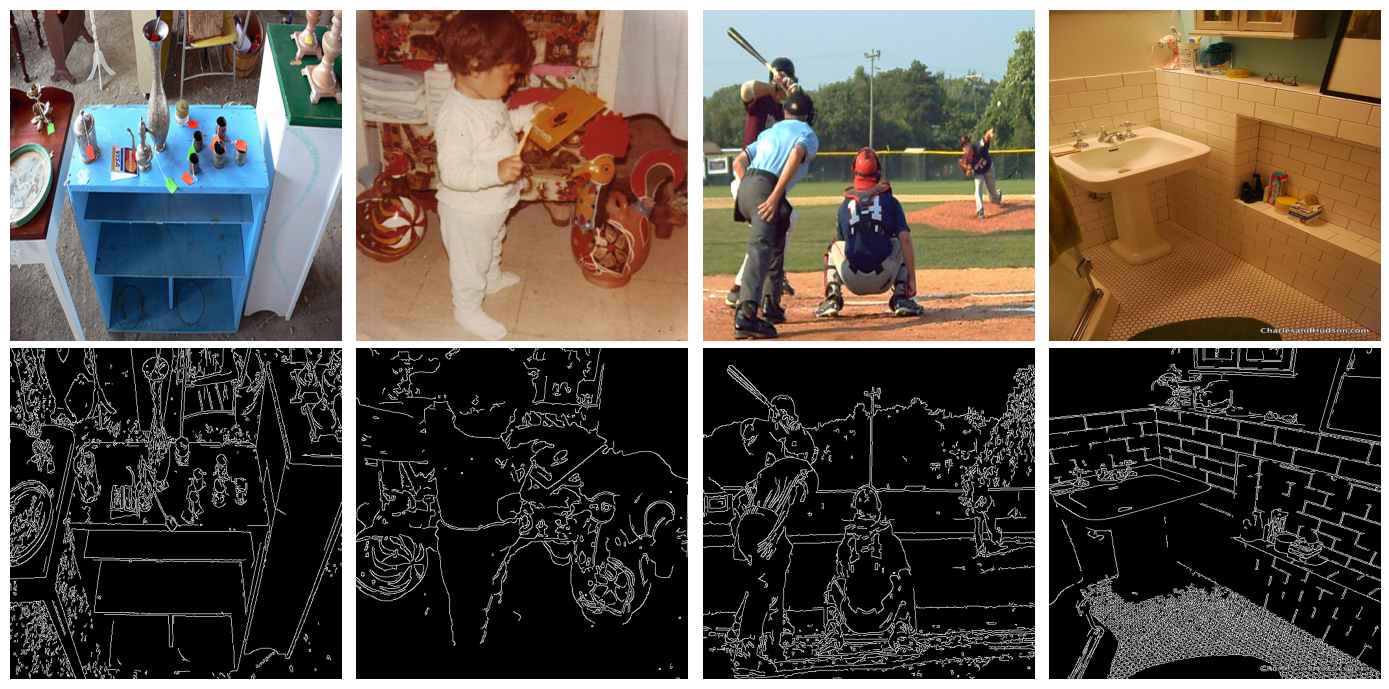

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    s = ds[i]
    img = ((s['pixel_values'] + 1) / 2).permute(1, 2, 0).numpy()
    cond = s['conditioning_pixel_values'].permute(1, 2, 0).numpy()
    axes[0, i].imshow(img); axes[0, i].axis('off')
    axes[1, i].imshow(cond); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

## 4. Architecture & correctness
Build the hand-written ControlNet from the SD U-Net and count trainable vs frozen params. Correctness is **proven**: `tests/test_parity_with_diffusers.py` asserts these residuals match `diffusers.ControlNetModel` to ~1e-4 given equal weights (`pytest tests/`).

In [4]:
from diffusers import UNet2DConditionModel
from src.models.controlnet import ControlNet
unet = UNet2DConditionModel.from_pretrained('runwayml/stable-diffusion-v1-5', subfolder='unet')
cn = ControlNet.from_unet(unet)
print(f'ControlNet (trainable):   {sum(p.numel() for p in cn.parameters()):>13,} params')
print(f'Frozen SD U-Net:          {sum(p.numel() for p in unet.parameters()):>13,} params')
print()
print('Correctness: tests/test_parity_with_diffusers.py asserts the residuals match')
print('diffusers.ControlNetModel to ~1e-4 given equal weights  ->  run: pytest tests/')
del unet, cn  # free CPU memory before the GPU inference below

A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "C:\Users\tobio\PycharmProjects\ControlNet-Implementation\.venv\Lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'triton'


ControlNet (trainable):     361,279,120 params
Frozen SD U-Net:            859,520,964 params

Correctness: tests/test_parity_with_diffusers.py asserts the residuals match
diffusers.ControlNetModel to ~1e-4 given equal weights  ->  run: pytest tests/


## 5. Training
Training runs from the repo root via `accelerate`:

```bash
# local smoke test (4GB GPU)
accelerate launch scripts/train.py --config configs/smoke_local.yaml
# full run (24-32GB)
accelerate launch scripts/train.py --config configs/runpod_24gb.yaml
```

Only the ControlNet trains (frozen VAE / text encoder / U-Net), with the DDPM noise-prediction loss and 50% prompt dropout. **Note on the loss:** for ControlNet it stays roughly *flat and noisy* (~0.10-0.20) throughout - the zero-conv init starts at the base model's already-good loss, and what actually changes is *spatial control*, which the loss barely reflects. The signal to watch is the **generated samples** following the condition (next section), not the loss number.

## 6. Results - control OFF vs ON
Load the trained checkpoint and generate each prompt **twice from the same seed**: once with the ControlNet switched off (`controlnet_conditioning_scale=0`) and once on. The OFF column ignores the Canny edges; the ON column follows them - that side-by-side is the clearest proof the ControlNet works. The figure is saved to `assets/comparison.png` (the README hero). Memory-safe for small GPUs (attention/VAE slicing + resolution fallback).

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded C:\Users\tobio\PycharmProjects\ControlNet-Implementation\outputs\runpod\controlnet-final.safetensors (missing=0, unexpected=0)
Initialized ControlNet inference for canny conditioning


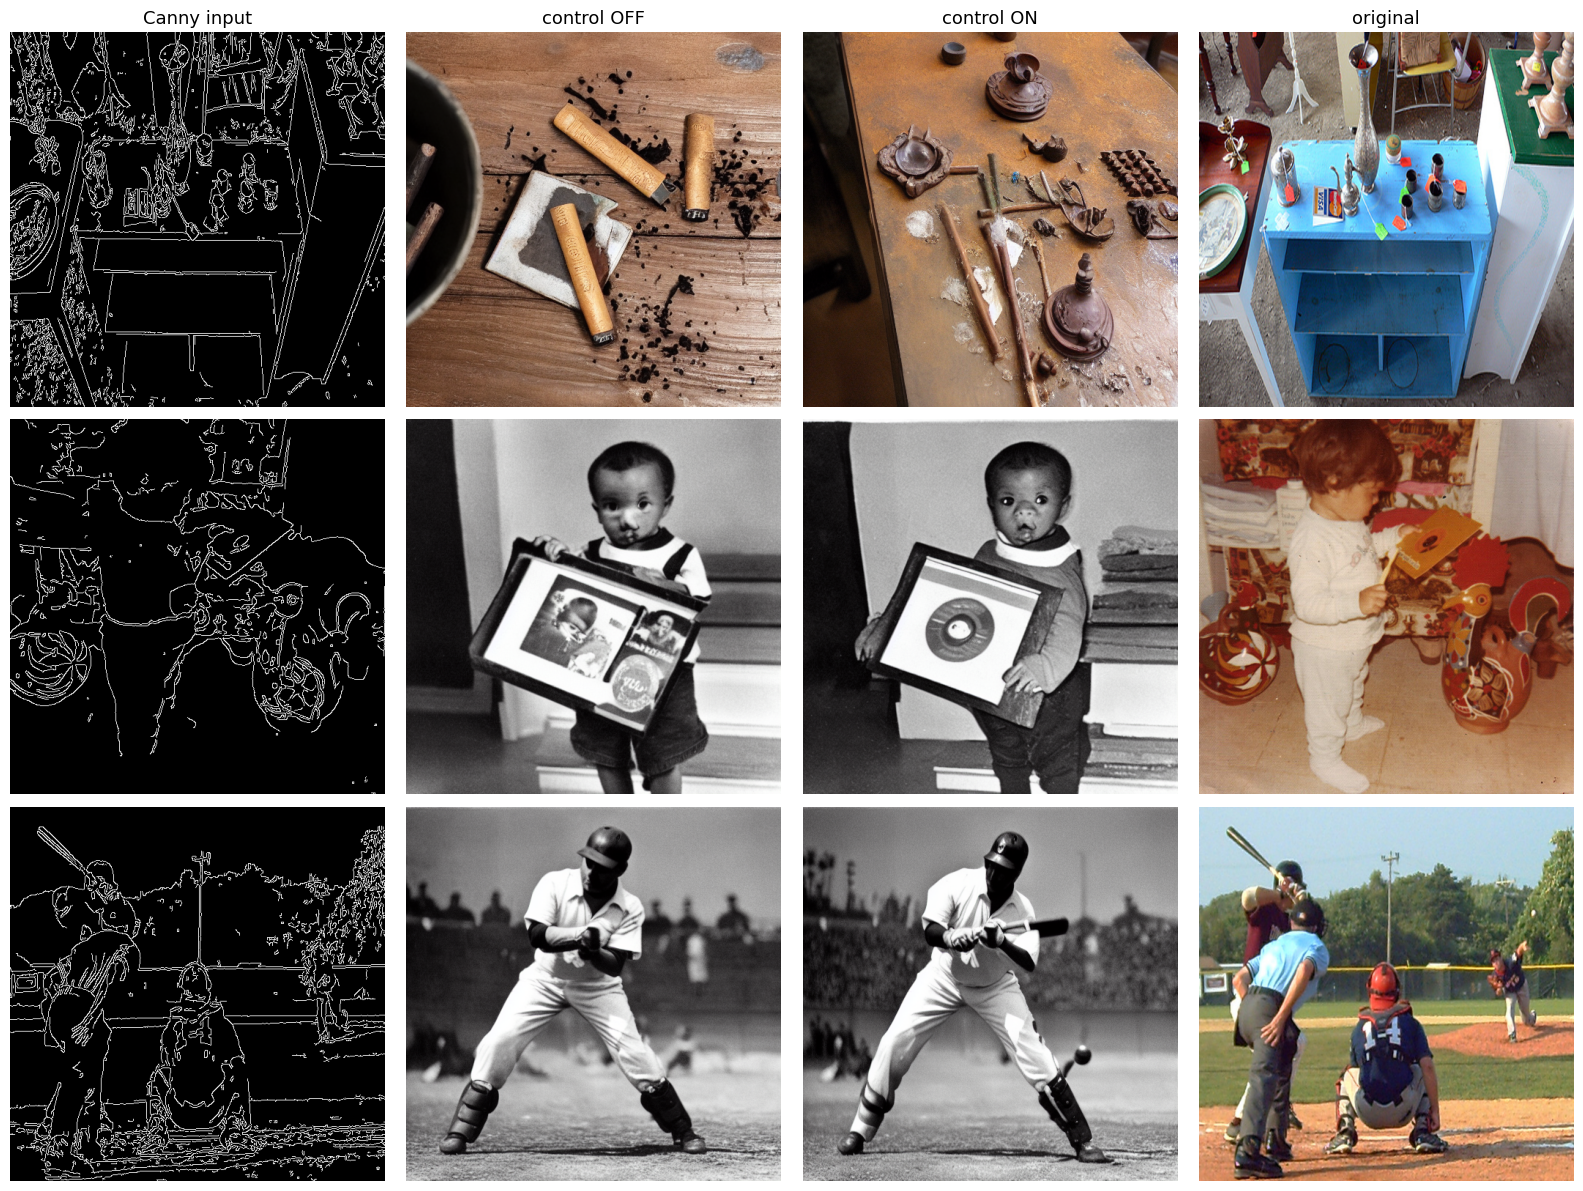

In [5]:
from src.inference.generate import ControlNetInference
CKPT = ROOT / 'outputs/runpod/controlnet-final.safetensors'
infer = ControlNetInference(controlnet_path=str(CKPT), condition_type='canny',
                            device='cuda' if torch.cuda.is_available() else 'cpu')
infer.pipe.enable_attention_slicing(); infer.pipe.enable_vae_slicing()

def gen(caption, image, scale):
    for res in [512, 384, 256]:
        try:
            return infer.generate(caption, Image.fromarray(image), num_inference_steps=25,
                                  image_resolution=res, controlnet_conditioning_scale=scale, seed=0)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()

samples = [json.loads(l) for l in open(ROOT / 'data/coco/val.jsonl')][:3]
cols = ['Canny input', 'control OFF', 'control ON', 'original']
fig, ax = plt.subplots(3, 4, figsize=(16, 12))
for i, s in enumerate(samples):
    img = np.array(Image.open(ROOT / 'data/coco' / s['image']).convert('RGB').resize((512, 512)))
    edges = cv2.Canny(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), 100, 200)
    off = gen(s['caption'], img, 0.0)
    on = gen(s['caption'], img, 1.0)
    for j, im in enumerate([edges, off, on, img]):
        ax[i, j].imshow(im, cmap='gray' if j == 0 else None); ax[i, j].axis('off')
        if i == 0:
            ax[i, j].set_title(cols[j], fontsize=13)
plt.tight_layout()
(ROOT / 'assets').mkdir(exist_ok=True)
plt.savefig(ROOT / 'assets/comparison.png', dpi=90, bbox_inches='tight')
plt.show()

## 7. Evaluation
`python scripts/evaluate.py --controlnet outputs/runpod/controlnet-final.safetensors --config configs/runpod_24gb.yaml --num-samples 100` writes `outputs/eval_report.json`; add `--conditioning-scale 0.0 --output outputs/eval_baseline.json` for the control-off baseline. **Canny edge-F1 / SSIM** is the ControlNet-specific metric (did the generation follow the control); **CLIP score** measures text-image alignment.

In [6]:
for name, path in [('control ON', 'outputs/eval_report.json'), ('control OFF', 'outputs/eval_baseline.json')]:
    p = ROOT / path
    if p.exists():
        r = json.load(open(p))
        print(f"{name:12} edge_f1={r['canny_edge_f1']:.3f}  ssim={r['canny_ssim']:.3f}  clip={r['clip_score']:.1f}")
    else:
        print(f'{name}: run scripts/evaluate.py to produce {path}')

control ON   edge_f1=0.083  ssim=0.370  clip=32.2
control OFF  edge_f1=0.084  ssim=0.354  clip=31.8
